## Load libraries and modules

In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
from numpy import sin, cos, pi

# Metrics

In [2]:
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse

In [3]:
def rel_err(y_true,y_pred):
    return np.abs((y_true - y_pred)/y_true)

def rmse_pt(y_true,y_pred):
    return np.abs(y_true - y_pred)

# Model
## Noiseless model

In [4]:
def analytical(theta:float,beta:float,alpha:float):
    return (\
        cos(alpha)**4 + sin(alpha)**4 +\
        2 * (sin(alpha)**2) * (cos(alpha)**2) * cos(theta) + \
        cos(alpha+beta)**4 + sin(alpha+beta)**4 + \
        2 * (sin(alpha+beta)**2) * (cos(alpha+beta)**2) * cos(theta)\
        )/2

## Noisy Model

In [5]:
def f(θ, Pt, Pϕ, ϕ):
    """
     θ  = Relative phase angle
     Pt = probability of getting the desired phased Bell's state
     Pϕ = Probability of measuring in the direction ϕ
     ϕ  = Direction of medition
    """
    return Pt * Pϕ * ( cos(ϕ)**4 + sin(ϕ)**4 + 2 * (sin(ϕ)**2) * (cos(ϕ)**2) * cos(θ) ) / 2

def ξ(Pe, Pϕ, ϕ):
    """
    Pe = Probability of noise/error 
    Pϕ = Probability of measuring in the direction ϕ
    ϕ  = Direction of medition
    Pϵ = Probability of decay  with polarization ϵ {P_HH, P_HV,P_VH,P_VV}
         it depends on the experiments { fidelity & Tr(ρ) }
    """
    P_HH, P_HV,P_VH,P_VV = [0.25 , 0.25 , 0.25 , 0.25]
    
    return Pe * Pϕ * (P_HH * (sin(ϕ)**4 + cos(ϕ)**4) + 2 * (P_HV + P_VH) * (sin(ϕ)**2) * (cos(ϕ)**2) + P_VV * (sin(ϕ)**4 + cos(ϕ)**4) )
    
def Π_err(α,β,θ,Pt):
    Pt = Pt / 100. # from percent to unit
    Pe = 1 - Pt
    return f(θ,Pt,1/2,α) + ξ(Pe,1/2,α) + f(θ,Pt,1/2,α+β) + ξ(Pe,1/2,α+β)

def model_noise(θ,α,β,Pt):
    return analytical(θ,β,α)*Pt + ((1-Pt)/2.0)

## Noise-based Model

# Data description

| path | Description  | noise $\%$|
|---------------------|-------------|-------------|
|`runs`               | gridsize $20^{2}$ N_states = 1,5,10,15,20,25,30,35,40,45 (K)  | $\begin{pmatrix}0& 0.1& 4 \end{pmatrix}$|
|`runs`               | Probabilities taken from Chen's paper and tiny noise  | $\begin{pmatrix}0& 0.1& 4 \end{pmatrix}$|
|`fixed point`        | $\theta=\pi/3$, $\beta = \pi/4$ non parametrized| $\begin{pmatrix}0 & 0.1 & 0.2 \end{pmatrix}$|
|`fixed error results`| bad simulations with inconsistent number of states and different grid sizes | 30  too much  |

In [6]:
reviewed_probability_filenames = pd.read_csv("./runs/filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()
noisy_probability_filenames = pd.read_csv("./runs/noisy_filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()

## Join data in concatenated Data Frames

In [7]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

path = './runs/'
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

noiseless_r2 = list()
noiseless_mse = list()
noiseless_rmse = list()

noisy_r2 = list()
noisy_mse = list()
noisy_rmse = list()

model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

for experiment_name in reviewed_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noiseless_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noiseless_mse.append( (mse(y_true=model,y_pred=experiment) ))
    noiseless_rmse.append( (rmse(y_true=model,y_pred=experiment) ))

for experiment_name in noisy_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noisy_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noisy_mse.append( mse(y_true=model,y_pred=experiment) )
    noisy_rmse.append( rmse(y_true=model,y_pred=experiment) )
    
"""
N_states = pd.DataFrame(dict(zip(['N_states'],[[1.0E3,5.0E3,1.0E4,1.5E4,2.0E4,2.5E4,3.0E4,3.5E4,4.0E4,4.5E4]])))
df_reviewed = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[0.0 for k in range(len (noiseless_mse))],noiseless_r2,noiseless_rmse,noiseless_mse])) )
df_noisy = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[9.0 for k in range(len(noisy_mse))],noisy_r2,noisy_rmse,noisy_mse])) )
"""
N_states_list = [1.0E3, 5.0E3, 1.0E4, 1.5E4, 2.0E4, 2.5E4, 3.0E4, 3.5E4, 4.0E4, 4.5E4]

df_reviewed = pd.DataFrame({
    'Noise': 0.0,
    'R2': noiseless_r2,
    'RMSE': noiseless_rmse,
    'MSE': noiseless_mse,
    'N_states': N_states_list
})

df_noisy = pd.DataFrame({
    'Noise': 9.0,
    'R2': noisy_r2,
    'RMSE': noisy_rmse,
    'MSE': noisy_mse,
    'N_states': N_states_list
})

# Concatenamos de forma limpia
results = pd.concat([df_reviewed, df_noisy], ignore_index=True)

# Plots

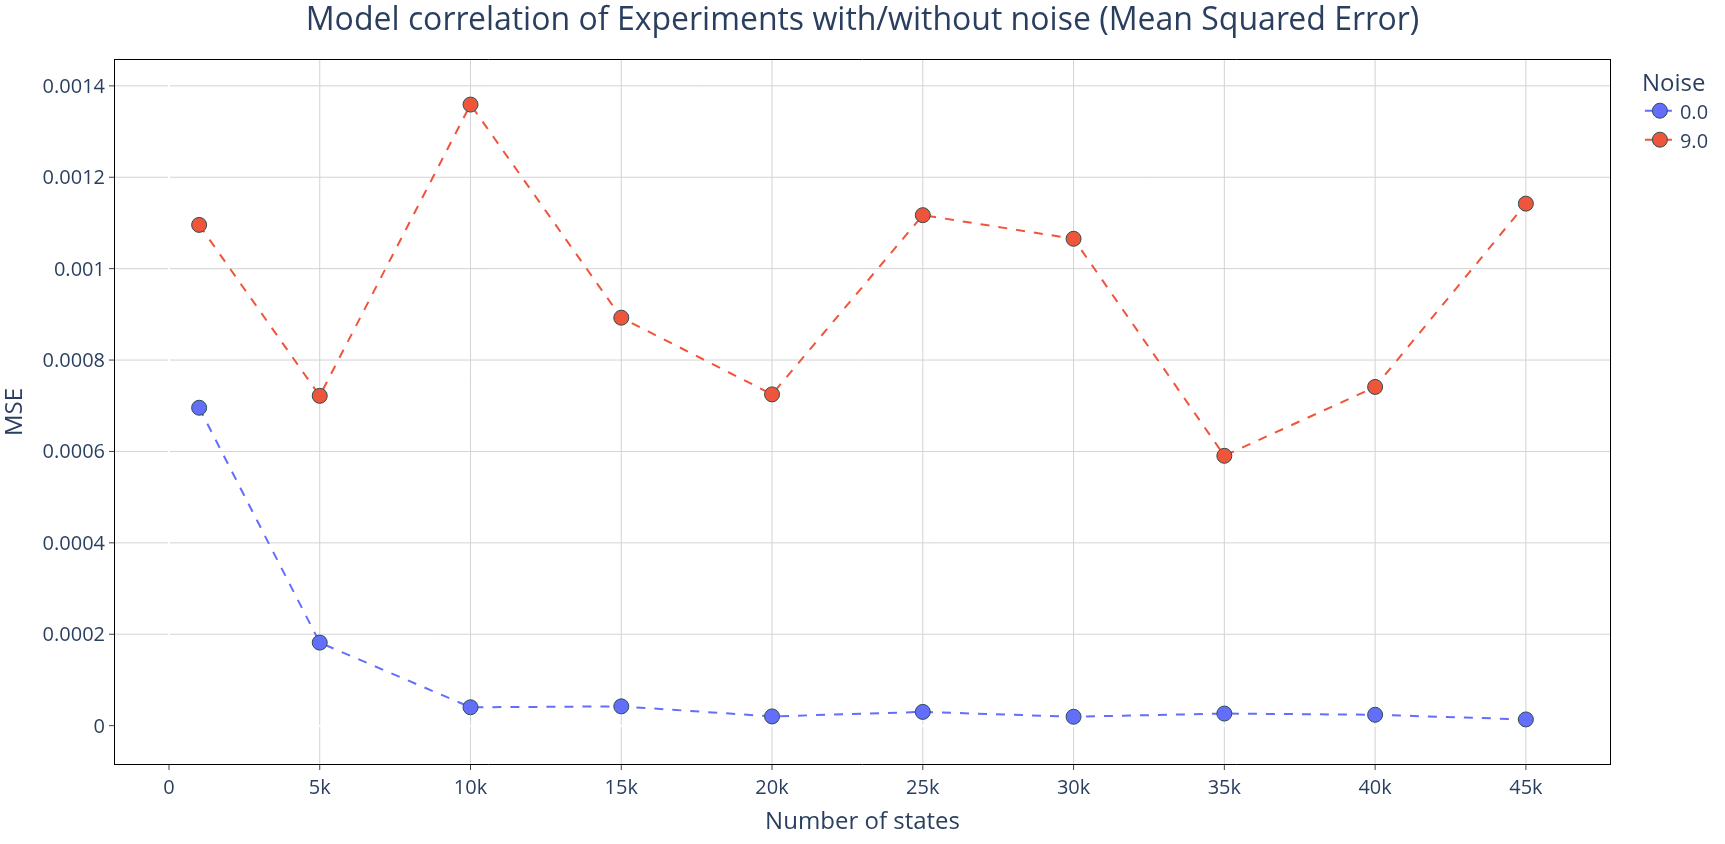

In [8]:
# Configuración del subplot
fig = px.line(results,
              x = 'N_states',
              y = 'MSE',
              color = 'Noise',
              markers = True
              )
fig.update_traces(marker=dict(size=15,line=dict(width=1, color='DarkSlateGrey')),
                  line_dash='dash'
                 )
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise (Mean Squared Error)",
        'font': {'size': 32},
        'x' :0.5
    }
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    #type='log',
    title_text='MSE',
    #title_text='Log  (MSE)'
)
#fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="lightgrey", annotation_text="Target MSE", annotation_position="top left")
fig.show()

### scalation of metrics to reduce dispersion and enhance visualization

In [9]:
from sklearn.preprocessing import StandardScaler as zscaler

In [10]:
# Create an empty DataFrame with the exact same index as 'results'
scaled_results = pd.DataFrame(index=results.index, columns=['R2 scaled', 'RMSE scaled', 'MSE scaled'])

# Create masks to isolate each experiment
mask_0 = results['Noise'] == 0.0
mask_9 = results['Noise'] == 9.0

# Initialize independent scalers
scaler_0 = zscaler()
scaler_9 = zscaler()

# Fit and transform independently, then assign back
scaled_results.loc[mask_0, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_0.fit_transform(results.loc[mask_0, ['R2', 'RMSE', 'MSE']])
scaled_results.loc[mask_9, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_9.fit_transform(results.loc[mask_9, ['R2', 'RMSE', 'MSE']])

# Ensure the columns are strictly float types so Plotly handles them correctly
scaled_results = scaled_results.astype(float)

In [11]:
# Ensure the columns are strictly float types so Plotly handles them correctly
scaled_results = scaled_results.astype(float)

# Concatenate normally. DO NOT overwrite with only scaled_results.
results_df = pd.concat([results, scaled_results], axis=1)
results_df.head()

,Noise,R2,RMSE,MSE,N_states,R2 scaled,RMSE scaled,MSE scaled
0,0.0,0.082469,0.024327,0.000696,1000.0,2.962199,2.772724,2.917231
1,0.0,0.015119,0.012150,0.000182,5000.0,0.109073,0.766359,0.360085
2,0.0,0.006576,0.006111,0.000040,10000.0,-0.252809,-0.228699,-0.344029
3,0.0,0.005322,0.006116,0.000042,15000.0,-0.305967,-0.227755,-0.334086
4,0.0,0.003639,0.004385,0.000020,20000.0,-0.377253,-0.513026,-0.443612


In [12]:
results.head()


,Noise,R2,RMSE,MSE,N_states
0,0.0,0.082469,0.024327,0.000696,1000.0
1,0.0,0.015119,0.012150,0.000182,5000.0
2,0.0,0.006576,0.006111,0.000040,10000.0
3,0.0,0.005322,0.006116,0.000042,15000.0
4,0.0,0.003639,0.004385,0.000020,20000.0


## Metrics dispersion

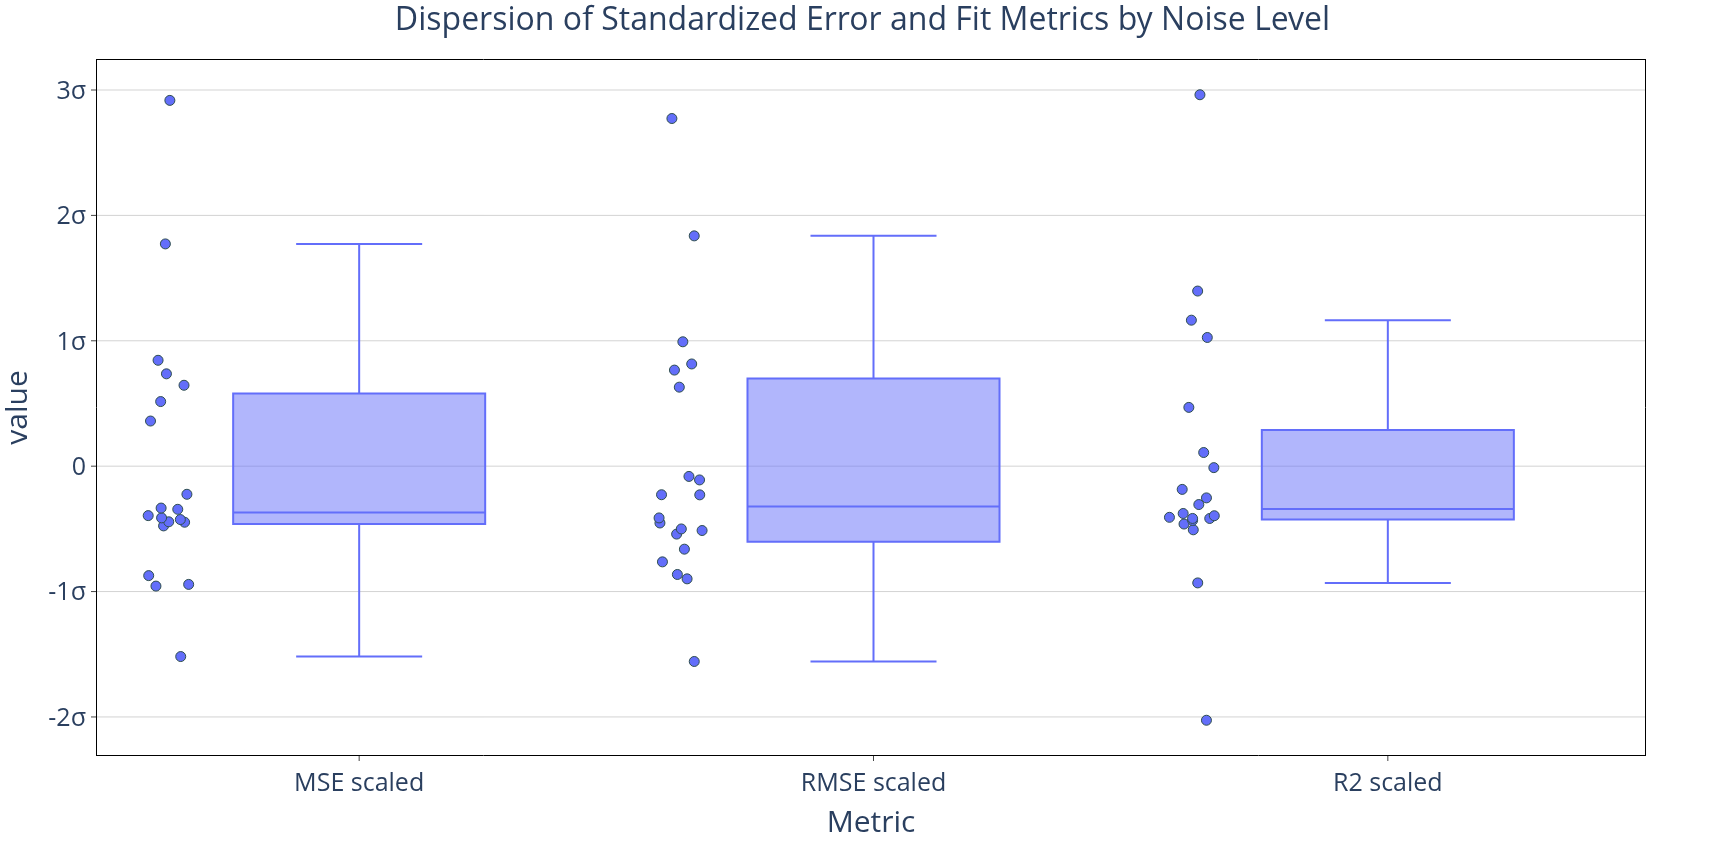

In [13]:
tick_values = [k for k in range(-3,4)]
tick_labels = ['0' if val == 0 else f'{val}σ' for val in tick_values]

fig = px.box(results_df,
       y = ['MSE scaled', 'RMSE scaled','R2 scaled'],
       points='all',
    #color='Noise',
       height = 844,
       width = 1500,
            )
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
                  selector=dict(type='box'))

fig.update_layout(
    title={
        'text': "Dispersion of Standardized Error and Fit Metrics by Noise Level",
        'font': {'size': 32},
        'x' :0.5
    },
    font=dict(size=25),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    title_text='Metric',
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    zerolinecolor='LightGray', 
    zerolinewidth=1,
    linecolor='black',
    gridcolor='lightgrey',
    tickmode='array', # Explicitly set tickmode to 'array'
    tickvals=tick_values,
    ticktext=tick_labels,
)
fig.show()

## Messy results

## analytical model with error

## high error results

In [14]:
path = 'fixed error results/'


pure_filenames = ['pure_50x50_mesh_1E3_states_E91_data_2026_aer_simulator_25_02_2026_12_56_22',
                  'pure_50x50_mesh_5E3_states_E91_data_2026_aer_simulator_25_02_2026_14_33_00',
                  'pure_50x50_mesh_1E4_states_E91_data_2026_aer_simulator_25_02_2026_20_10_04',
                  'pure_50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_26_02_2026_15_59_56',
                  'pure_50x50_mesh_2E4_states_E91_data_2026_aer_simulator_25_02_2026_22_54_49']

error_filenames= ['50x50_mesh_1E3_states_E91_data_2026_aer_simulator_23_02_2026_18_32_14',
                  '50x50_mesh_5E3_states_E91_data_2026_aer_simulator_23_02_2026_14_22_55',
                  '50x50_mesh_1E4_estates_E91_data_2026_aer_simulator_23_02_2026_14_36_26',
                  '50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_23_02_2026_23_12_07',
                  '50x50_mesh_2E4_states_E91_data_2026_aer_simulator_24_02_2026_07_12_29',
                  '50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03']

test_filenames= ['10x10_mesh_1E3_E91_data_2026_aer_simulator_02_03_2026_15_36_28',
                 '10x10_mesh_1E4_states_E91_data_2026_aer_simulator_02_03_2026_16_23_52',
                 '10x10_mesh_1.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_08_36',
                 '10x10_mesh_2E4_states_E91_data_2026_aer_simulator_02_03_2026_19_41_56',
                 '10x10_mesh_2.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_04_56',
                 '10x10_3E4_states_E91_data_2026_aer_simulator_02_03_2026_15_54_44',
                 '10x10_mesh_3.5E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_08',
                 '10x10_mesh_4E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_51',]

In [15]:
# OPTIMIZATION: Calculate static ideal models ONCE here using vectorized meshgrids

# 10x10 Model
theta_10 = np.linspace(0, 2*np.pi, 10)
beta_10 = np.linspace(0, np.pi, 10)
T_10, B_10 = np.meshgrid(theta_10, beta_10, indexing='ij')
# Vectorized calculation
model_10_ideal = analytical(theta=T_10, beta=B_10, alpha=alpha)

# 50x50 Model (we can use this exact same model for both pure and error loops)
theta_50 = np.linspace(0, 2*np.pi, 50)
beta_50 = np.linspace(0, np.pi, 50)
T_50, B_50 = np.meshgrid(theta_50, beta_50, indexing='ij')
# Vectorized calculation
model_50_ideal = analytical(theta=T_50, beta=B_50, alpha=alpha)

# DataFrame Formation

In [16]:
N_data = 20

theta_FSS = np.linspace(0, 2*pi, N_data)
beta_angle = np.linspace(0, pi, N_data)
alpha = pi/16

# Base model (from your original code)
experiment_number = 5
model = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

# Initialize metric lists
correlation_10_error = []
mse_10_error = []
r2_10_error = []

correlation_50_error = []
mse_50_error = []
r2_50_error = []

correlation_50_pure = []
mse_50_pure = []
r2_50_pure = []

mse_15_tiny_noise = []
correlation_15_tiny_noise = []
r2_15_tiny_noise = []

mse_20_tiny_noise = []
correlation_20_tiny_noise = []
r2_20_tiny_noise = []

rel_err_single_pt_noiseless = []
rel_err_single_pt_noisy = []

# =========================================================
# OPTIMIZATION: Calculate static ideal models ONCE here
# =========================================================
# 10x10 Model
theta_10 = np.linspace(0, 2*pi, 10)
beta_10 = np.linspace(0, pi, 10)
model_10_ideal = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_10] for t in theta_10])

# 50x50 Model (We can use this exact same model for both pure and error loops!)
theta_50 = np.linspace(0, 2*pi, 50)
beta_50 = np.linspace(0, pi, 50)
model_50_ideal = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_50] for t in theta_50])
# =========================================================

# Loop 1: test_filenames (10x10)
for experiment_name in test_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values    
    
    # Calculate and append metrics using the pre-calculated model
    correlation_10_error.append( rmse(y_true=model_10_ideal, y_pred=experiment) )
    mse_10_error.append( mse(y_true=model_10_ideal, y_pred=experiment) )
    r2_10_error.append( r2(y_true=model_10_ideal, y_pred=experiment) )
    
# Loop 2: error_filenames (50x50)
for experiment_name in error_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values
    
    # Calculate and append metrics using the pre-calculated model
    correlation_50_error.append( rmse(y_true=model_50_ideal, y_pred=experiment) )
    mse_50_error.append( mse(y_true=model_50_ideal, y_pred=experiment) )
    r2_50_error.append( r2(y_true=model_50_ideal, y_pred=experiment) )
    
# Loop 3: pure_filenames (50x50)
for experiment_name in pure_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values
    
    # Calculate and append metrics using the pre-calculated model
    correlation_50_pure.append( rmse(y_true=model_50_ideal, y_pred=experiment) )
    mse_50_pure.append( mse(y_true=model_50_ideal, y_pred=experiment) )
    r2_50_pure.append( r2(y_true=model_50_ideal, y_pred=experiment) )

# Loop 4: tiny_noise runs (Dynamic sizes using len(experiment))
path1 = "./runs/"
for experiment_name in pd.read_csv(path1+'test_filenames.csv',header=None).values.flatten():
    experiment = pd.read_csv(path1+experiment_name, header=None).dropna(axis=1, how='all').values
    
    # This remains inside the loop because its dimension scales dynamically with len(experiment)
    dim = len(experiment)
    theta_dyn = np.linspace(0, 2*pi, dim)
    beta_dyn = np.linspace(0, pi, dim)
    model_dyn = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_dyn] for t in theta_dyn])
    
    # Calculate and append metrics
    correlation_15_tiny_noise.append( rmse(y_true=model_dyn, y_pred=experiment) )
    mse_15_tiny_noise.append( mse(y_true=model_dyn, y_pred=experiment) )
    r2_15_tiny_noise.append( 1 - r2(y_true=model_dyn, y_pred=experiment) )

for experiment_name in pd.read_csv(path1+'tiny_noise_filenames.csv',header=None).dropna(axis=1, how='all').values.flatten():
    experiment = pd.read_csv(path1+experiment_name, header=None).dropna(axis=1, how='all').values
    
    # This remains inside the loop because its dimension scales dynamically with len(experiment)
    dim = len(experiment)
    theta_dyn = np.linspace(0, 2*pi, dim)
    beta_dyn = np.linspace(0, pi, dim)
    model_dyn = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_dyn] for t in theta_dyn])
    
    # Calculate and append metrics
    correlation_20_tiny_noise.append( rmse(y_true=model_dyn, y_pred=experiment) )
    mse_20_tiny_noise.append( mse(y_true=model_dyn, y_pred=experiment) )
    r2_20_tiny_noise.append( 1 - r2(y_true=model_dyn, y_pred=experiment) )
    

# Single point experiments
path2 = "./fixed point/"
for n,experiment_name in enumerate(pd.read_csv(path2+'filenames_fixed_point_noiseless.csv',header=None).dropna(axis=1, how='all').values.flatten()):
    experiment = pd.read_csv(path2+experiment_name,header=None).dropna(axis=1, how='all').values.flatten()
    dim = len(experiment)
    model_single_pt = [analytical(theta=pi/3,beta=pi/4,alpha=alpha) for k in range(dim)]
    rel_err_single_pt_noiseless.append([])
    for k in range(dim):
        rel_err_single_pt_noiseless[n].append(rel_err(y_true=model_single_pt[k],y_pred=experiment[k]))

for n,experiment_name in enumerate(pd.read_csv(path2+'filenames_fixed_point_noisy.csv',header=None).dropna(axis=1, how='all').values.flatten()):
    experiment = pd.read_csv(path2+experiment_name,header=None).dropna(axis=1, how='all').values.flatten()
    dim = len(experiment)
    model_single_pt = [analytical(theta=pi/3,beta=pi/4,alpha=alpha) for k in range(dim)]
    rel_err_single_pt_noisy.append([])
    for k in range(dim):
        rel_err_single_pt_noisy[n].append(rel_err(y_true=model_single_pt[k],y_pred=experiment[k]))


# ==========================
# Creación de los DataFrames
# ==========================

# BUG FIX: Added the missing df_10_error DataFrame back in!
df_10_error = pd.DataFrame({
    'Nstates': [1E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4], 
    'RMSE': correlation_10_error,
    'MSE': mse_10_error,
    'R2': r2_10_error
})

df_50_pure = pd.DataFrame({
    'Nstates': [1E3, 1E4, 1.5E4, 2E4, 2.5E4],
    'RMSE': correlation_50_pure,
    'MSE': mse_50_pure,
    'R2': r2_50_pure
})

df_50_error = pd.DataFrame({
    'Nstates': [1E3, 5E3, 1E4, 1.5E4, 2E4, 2.5E4],
    
    'RMSE': correlation_50_error,
    'MSE': mse_50_error,
    'R2': r2_50_error
})

df_15_tiny_noise = pd.DataFrame({
    'Nstates': [1E3, 5E3, 1E4],
    'RMSE': correlation_15_tiny_noise,
    'MSE': mse_15_tiny_noise,
    'R2': r2_15_tiny_noise
})

df_20_tiny_noise = pd.DataFrame({
    'Nstates': [1E3,5E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4, 4.5E4],
    'RMSE': correlation_20_tiny_noise,
    'MSE': mse_20_tiny_noise,
    'R2': r2_20_tiny_noise
})

df_single_pt_noiseless = pd.DataFrame({
    'Nstates': [1E3,5E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4, 4.5E4], 
    'run 1': rel_err_single_pt_noiseless[0],
    'run 2': rel_err_single_pt_noiseless[1],
    'run 3': rel_err_single_pt_noiseless[2]
})
df_single_pt_noisy = pd.DataFrame({
    'Nstates': [1E3,5E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4, 4.5E4], 
    'run 1': rel_err_single_pt_noisy[0],
    'run 2': rel_err_single_pt_noisy[1],
    'run 3': rel_err_single_pt_noisy[2]
})

## Contrast All results

In [17]:
# Contrast All results
# In [17]: Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1
    # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Nstates'],
        y=df_50_pure['MSE'],
        mode='lines+markers',
        name='50 grid with 0% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Nstates'],
        y=df_50_error['MSE'],
        mode='lines+markers',
        name='50 grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Nstates'],
        y=df_10_error['MSE'],
        mode='lines+markers',
        name='10 grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_15_tiny_noise['Nstates'],
        y=df_15_tiny_noise['MSE'],
        mode='lines+markers',
        name='15 grid with tiny noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_20_tiny_noise['Nstates'],
        y=df_20_tiny_noise['MSE'],
        mode='lines+markers',
        name='20 grid with tiny noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

fig.add_trace(go.Scatter(
    x=results_df.loc[results_df['Noise'] == 0.0, 'N states'],
    y=results_df.loc[results_df['Noise'] == 0.0, 'MSE'],
    name="20 grid with 0% noise [Latest]",
    mode='lines+markers',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x=results_df.loc[results_df['Noise'] == 9.0, 'N states'],
    y=results_df.loc[results_df['Noise'] == 9.0, 'MSE'],
    name="20 grid with 9% error [Reference]",
    mode='lines+markers',
    line=dict(dash='dash')
))

# Note: Ensure df_single_pt is defined in your notebook prior to this trace
if 'df_single_pt' in locals():
    fig.add_trace(go.Scatter(
        x=df_single_pt['Nstates'],
        y=df_single_pt['MSE'],
        mode='lines+markers',
        name='single point experiment noise',
        line=dict(dash='dash')
    ), row=1, col=1)

fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    height=844,
    width=1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title=dict(
        text="Model correlation of Experiments with/without noise (Mean Squared Error)",
        font=dict(size=32),
        x=0.5
    )
)

fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text="Number of states"
)

fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    type='log',
    title_text="Log (MSE)"
)

fig.show()

KeyError: 'N states'

## Single point results

In [ ]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
#"""
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noisy['Nstates'], 
        y=df_single_pt_noisy['run 1'], 
        mode='lines+markers', 
        name='run 1 noisy',
        #line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noisy['Nstates'], 
        y=df_single_pt_noisy['run 2'], 
        mode='lines+markers', 
        name='run 2 noisy',
        #line=dict(dash='dash')
    ),
    row=1, col=1
)
#"""
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noisy['Nstates'], 
        y=df_single_pt_noisy['run 3'], 
        mode='lines+markers', 
        name='run 3 noisy',
        #line=dict(dash='dash')
    ),
    row=1, col=1
)
#"""
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noiseless['Nstates'], 
        y=df_single_pt_noiseless['run 1'], 
        mode='lines+markers', 
        name='run 1 noiseless',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noiseless['Nstates'], 
        y=df_single_pt_noiseless['run 2'], 
        mode='lines+markers', 
        name='run 2 noiseless',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
#"""
fig.add_trace(
    go.Scatter(
        x=df_single_pt_noiseless['Nstates'], 
        y=df_single_pt_noiseless['run 3'], 
        mode='lines+markers', 
        name='run 3 noiseless',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

#fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise R2",
        'font': {'size': 32},
        'x' :0.2
    },
    #title_text="Root Mean Squared Error"
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'

)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    #type='log',
    title_text='Relative Error in a single point'
)
fig.show()



## Problems with $R{2}$

In [ ]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Nstates'], 
        y=df_50_pure['R2'], 
        mode='lines+markers', 
        name='50² grid with 0% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Nstates'], 
        y=df_50_error['R2'], 
        mode='lines+markers', 
        name='50² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Nstates'], 
        y=df_10_error['R2'], 
        mode='lines+markers', 
        name='10² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
"""
fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 0.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 0.0, 'R2'],
    name="20² grid with 0% noise [Latest]",
    mode='lines+markers',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 9.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 9.0, 'R2'],
    name="20² grid with 9% error [Reference]",
    mode='lines+markers',
    line=dict(dash='dash')
))
"""

fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise R2",
        'font': {'size': 32},
        'x' :0.2
    },
    #title_text="Root Mean Squared Error"
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'

)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    #type='log',
    title_text='R2'
)
fig.show()



## Data Standarization via Zscale

In [ ]:
import plotly.io as pio

# Set renderer to 'notebook_connected' for Jupyter or 'vscode' for VS Code
# This helps load the MathJax library needed for LaTeX
pio.renderers.default = "notebook_connected" 

# Data Setup
N_samples = 100
P_e = 0.1
alpha_val = π/8
beta_val = 3*π/8
theta_range = np.linspace(0, 2*π, N_samples)

# Generate Y values
y_pure = model_analytical(theta_range, beta_val, alpha_val)
y_noisy = model_new_noisy(theta_range, beta_val, alpha_val, P_e)

fig = go.Figure()

# Add Noiseless Trace
fig.add_trace(go.Scatter(
    x=theta_range, 
    y=y_pure,
    name=r"$\text{Pure Model } (P_e=0)$",
    mode='lines',
    line=dict(color='#636EFA', width=2.5)
))

# Add Noisy Trace
fig.add_trace(go.Scatter(
    x=theta_range, 
    y=y_noisy,
    name=fr"$\text{{Noisy Model }} (P_e={P_e})$",
    mode='lines',
    line=dict(color='#EF553B', width=2.5, dash='dash')
))

# Layout with LaTeX formatting
fig.update_layout(
    title=dict(
        text=r"$\text{Model Contrast: Effect of Noise } P_e \text{ on Signal Amplitude}$",
        font=dict(size=24),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title=r"$\theta \text{ [rad]}$",
        tickmode='array',
        tickvals=[0, π/2, π, 3*π/2, 2*π],
        ticktext=[r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
        range=[0, 2*π],
        gridcolor='rgba(200, 200, 200, 0.2)'
    ),
    yaxis=dict(
        title=r"$\text{Probability } P(\theta)$",
        tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        range=[0, 1.05],
        gridcolor='rgba(200, 200, 200, 0.2)'
    ),
    width=800,
    height=500,
    template="plotly_white",
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()

In [ ]:
# Set up custom ticks for standard deviations
tick_values = [k for k in range(-3,4)]
tick_labels = ['0' if val == 0 else f'{val}σ' for val in tick_values]

# Generate the plot
fig = px.box(
    final_combined_df,
    y=['MSE scaled', 'RMSE scaled', 'R2 scaled'],
    color='Group',  # Grouping by our new label
    points='all',
    height=844,
    width=1500,
)

# Styling traces
fig.update_traces(
    marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(type='box')
)

# Styling layout
fig.update_layout(
    title={
        'text': "Effect of Experiment Type on Standardized Performance Metrics",
        'font': {'size': 32},
        'x': 0.5
    },
    font=dict(size=25),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend_title_text='Experiment Type' # Clarify the legend
)

# Styling X-axis
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    title_text='Metric',
)

# Styling Y-axis
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    zerolinecolor='LightGray', 
    zerolinewidth=1,
    linecolor='black',
    gridcolor='lightgrey',
    tickmode='array', 
    tickvals=tick_values,
    ticktext=tick_labels,
    title_text='Standard Deviations (\u03C3)' # Added y-axis label for clarity
)

fig.show()

## Surface Plots

In [ ]:
fig.update_layout(
    title='Performance parameter depending on the noise percentage',
    autosize=False,
    width=1000,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        yaxis_title='θ',
        xaxis_title='β',
        zaxis_title='Performance parameter',
        # Move xaxis here for 3D plots
        yaxis=dict(
            tickmode='array',
            tickvals=[0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
            ticktext=['0', 'π/4', 'π/2', '3π/4', 'π'],
            range=[0,  np.pi]
        ),
        # Move yaxis here and limit to pi
        xaxis=dict(
            tickmode='array',
            tickvals=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
            ticktext=['0', 'π/2', 'π', '3π/2', '2π'],
            range=[0, 2*np.pi]
        )
    ),
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=16) 
)

# Display the plot
fig.show()

In [ ]:
experiment_noiseless = pd.read_csv('fixed error results/pure_50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_28_02_2026_00_49_06.csv',header=None).dropna(axis=1,how='all').values
experiment_noisy = pd.read_csv('fixed error results/50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03.csv',header=None).dropna(axis=1,how='all').values
dim = len(experiment_noiseless)
θ = np.linspace(0, 2*np.pi ,dim)
β = np.linspace( 0, np.pi , dim)

model = np.array([[Π_err(np.pi/8,beta,theta,Pt=68) for beta in β] for theta in θ])

In [ ]:
fig = go.Figure()
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noisy, 
    colorscale='Emrld',
    opacity=.8,
    name='Noisy',
    colorbar=dict(title='noisy', x=1.5)
))
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = model, 
    colorscale='sunsetdark',
    opacity=.8,
    name='model',
    colorbar=dict(title='model', x=1.1)
))
"""
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noiseless, 
    #colorscale='viridis',
    opacity=.8,
    name='Noiseless',
    colorbar=dict(title='noiseless', x=1.3)
))
"""
# Customize the layout for better visualization
fig.update_layout(
    title=f"Noiseless Experiment Square residuals\rμ={np.mean(np.square(model - experiment_noiseless)):.2e}",
    autosize=False,
    width=1000,
    height=800,
    margin=dict(l=65, r=60, b=65, t=90),
    scene=dict(
        xaxis_title='θs',
        yaxis_title='β',
        zaxis_title='data',
        zaxis=dict(range=[0,1])
    ),
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=16)
)

# Display the plot
fig.show()

In [ ]:
experiment_noiseless = pd.read_csv('fixed error results/pure_50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_28_02_2026_00_49_06.csv',header=None).dropna(axis=1,how='all').values
experiment_noisy = pd.read_csv('fixed error results/50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03.csv',header=None).dropna(axis=1,how='all').values
dim = len(experiment_noiseless)

θ = np.linspace(0, 2*np.pi, dim)
β = np.linspace(0, np.pi, dim)

# Pre-calcular ambos modelos para mantener el gráfico limpio
model = np.array([[model_noise(theta, np.pi/16, beta, Pt=(68/100)) for beta in β] for theta in θ])
model_pure = np.array([[model_noise(theta, np.pi/16, beta, Pt=(1)) for beta in β] for theta in θ])

fig = go.Figure()

# --- Grupo de 30% Error (Colores Cálidos, sin blanco) ---
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noisy, 
    colorscale='Inferno',  # Cálido, oscuro a brillante (sin blanco)
    opacity=0.95,          # Opacidad alta para datos sólidos
    name='Noisy Experiment',
    colorbar=dict(
        title=dict(text='Exp. ϵ=30%', font=dict(size=13)), 
        x=1.02, 
        thickness=15
    )
))

fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = model, 
    colorscale='Solar',    # Rojos/Naranjas sólidos (sin blanco)
    opacity=0.45,          # Translúcido para ver el experimento a través
    name='Noisy Model',
    colorbar=dict(
        title=dict(text='Theo ϵ=30%', font=dict(size=13)), 
        x=1.12, 
        thickness=15
    )
))

# --- Grupo de 0% Error (Colores Fríos, sin blanco) ---
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noiseless, 
    colorscale='Viridis',  # Morado/Verde/Amarillo (sin blanco)
    opacity=0.95,
    name='Noiseless Experiment',
    colorbar=dict(
        title=dict(text='Exp. ϵ=0%', font=dict(size=13)), 
        x=1.22, 
        thickness=15
    )
))

fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = model_pure, 
    colorscale='Deep',     # Azules profundos (sin blanco)
    opacity=0.45,
    name='Noiseless Model',
    colorbar=dict(
        title=dict(text='Model. ϵ=0%', font=dict(size=13)), 
        x=1.32, 
        thickness=15
    )
))

# Customize the layout
fig.update_layout(
    title=dict(
        text=f"Noisy Experiment correlation <br>R<sup>2</sup>={r2(y_true=model,y_pred=experiment_noisy):1.4f}",
        x = 0.5,
        font=dict(size=24)
    ),
    autosize=False,
    width=1100, 
    height=800,
    margin=dict(l=65, r=60, b=65, t=90),
    scene=dict(
        xaxis=dict(
            title='β',
            tickmode='array',
            tickvals=[0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
            ticktext=['0', 'π/4', 'π/2', '3π/4', 'π']
        ),
        yaxis=dict(
            title='θ',
            tickmode='array',
            tickvals=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
            ticktext=['0', 'π/2', 'π', '3π/2', '2π']
        ),
        zaxis_title='Probability',
        zaxis=dict(range=[0,1])
    ),
    font=dict(size=16)
)

fig.show()

In [ ]:
model = np.array([[model_noise(theta, np.pi/16, beta, Pt=(68/100)) for beta in β] for theta in θ])
model_pure = np.array([[model_noise(theta, np.pi/16, beta, Pt=(1)) for beta in β] for theta in θ])

# 3. Configuración de Subplots (1 fila, 2 columnas)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'is_3d': True}, {'is_3d': True}]],
    subplot_titles=(
        f"0% Error<br>R<sup>2</sup> = {r2(y_true=model_pure, y_pred=experiment_noiseless):.4f}",
        f"30% Error<br>R<sup>2</sup> = {r2(y_true=model, y_pred=experiment_noisy):.4f}"
    )
)

# ==========================================
# SUBPLOT 1: 0% ERROR (Colores Fríos)
# ==========================================
fig.add_trace(go.Surface(
    x=β, y=θ, z=experiment_noiseless, 
    colorscale='Aggrnyl', opacity=1, name='Noiseless Experiment',
    colorbar=dict(title=dict(text='Exp', font=dict(size=12)), x=0.46, len=0.7, thickness=12)
), row=1, col=1)

fig.add_trace(go.Surface(
    x=β, y=θ, z=model_pure, 
    colorscale='Emrld', opacity=0.6, name='Noiseless Model',
    colorbar=dict(title=dict(text='Model', font=dict(size=12)), x=0.50, len=0.7, thickness=12)
), row=1, col=1)


# ==========================================
# SUBPLOT 2: 30% ERROR (Colores Cálidos)
# ==========================================
fig.add_trace(go.Surface(
    x=β, y=θ, z=experiment_noisy, 
    colorscale='Agsunset', opacity=1, name='Noisy Experiment',
    colorbar=dict(title=dict(text='Exp.', font=dict(size=12)), x=1.02, len=0.7, thickness=12)
), row=1, col=2)

fig.add_trace(go.Surface(
    x=β, y=θ, z=model, 
    colorscale='Sunsetdark', opacity=0.7, name='Noisy Model',
    colorbar=dict(title=dict(text='Model', font=dict(size=12)), x=1.06, len=0.7, thickness=12)
), row=1, col=2)

# ==========================================
# CONFIGURACIÓN DE EJES Y DISEÑO GENERAL
# ==========================================

# Plantilla compartida para los ejes (ticks en fracciones de pi)
axis_template = dict(
    xaxis=dict(
        title='β',
        tickmode='array',
        tickvals=[0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
        ticktext=['0', 'π/4', 'π/2', '3π/4', 'π']
    ),
    yaxis=dict(
        title='θ',
        tickmode='array',
        tickvals=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
        ticktext=['0', 'π/2', 'π', '3π/2', '2π']
    ),
    #zaxis_title='Probability',
    zaxis=dict(range=[0, 1])
)

fig.update_layout(
    title=dict(
        text="Theoretical vs Experimental Quantum State Probabilities",
        x=0.5, font=dict(size=22)
    ),
    autosize=False,
    width=1500,   # Más ancho para acomodar ambos gráficos cómodamente
    height=750,
    margin=dict(l=30, r=30, b=50, t=100),
    # Aplicamos la configuración de ejes a ambas escenas 3D generadas por el make_subplots
    scene=axis_template,
    scene2=axis_template,
    font=dict(size=14)
)

# Aumentar la fuente de los títulos de los subplots
for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=18)

fig.show()
fig.write_html("noise model for 2 noise distributions.html")

In [ ]:
exp_tiny_noise = pd.read_csv('runs/8_NOISY_20x20_mesh_4.0E+04_states_AER_SIM_18_03_2026_21_00_15.csv',header=None).dropna(axis=1,how='all',).values
dim = len(exp_tiny_noise)
print(f"size of experiment output = {exp_tiny_noise.shape}\ndimension = {dim}")
θ = np.linspace(0,2*np.pi,dim)
β = np.linspace(0,np.pi,dim)
Pt = 93.0/100.0
model_tiny_noise = np.array([[model_noise(theta,alpha,beta,Pt) for theta in θ] for beta in β],dtype=np.float64).transpose()
print(f"size of noise model = {model_tiny_noise.shape} ")

In [ ]:
error = np.linspace(0.85,1.0,100)
model_tiny_noise_study = [np.array([[model_noise(theta,alpha,beta,pt) for theta in θ] for beta in β],dtype=np.float64).transpose() for pt in error]
r2_values = np.array([r2(y_true=model_tiny_noise,y_pred=model_val) for model_val in model_tiny_noise_study],dtype=np.float64)
print(f"max = {max(r2_values)} in position k = {np.argmax(r2_values)} for pt = {error[np.argmax(r2_values)]} with an R² of {r2_values[np.argmax(r2_values)]}")

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x = error,
    y = r2_values,
    name='R2 metric for several options of error',
    mode='lines',
    line=dict(width=2,color='black')
))
fig.add_trace(go.Scatter(
    x=[error[np.argmax(r2_values)]],
    y=[r2_values[np.argmax(r2_values)]],
    name=f"max value in near {error[np.argmax(r2_values)]:1.5}",
    mode='markers',
    marker=dict(size=10)
                        ))
fig.update_layout(
    width=800,
    height=500,
    title=dict(text="R² evaluated for several percents of error",x=0.5,font=dict(size=25))
)

In [ ]:
fig = go.Figure()

fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = exp_tiny_noise, 
    colorscale='Agsunset',  # Cálido, oscuro a brillante (sin blanco)
    opacity=1,          # Opacidad alta para datos sólidos
    name='Tiny Noisy Experiment',
    colorbar=dict(
        title=dict(text=f"Exp. ϵ={(1-Pt)*100:2.1f}%", font=dict(size=13)), 
        x=1, 
        thickness=15
    )
))

fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = model_tiny_noise, 
    colorscale='Sunsetdark',    # Rojos/Naranjas sólidos (sin blanco)
    opacity=0.7,          # Translúcido para ver el experimento a través
    name='Noisy Model',
    colorbar=dict(
        title=dict(text=f"Theo ϵ={(1-Pt)*100:2.1f}%", font=dict(size=13)), 
        x=1.1, 
        thickness=15
    )
))


# Customize the layout
fig.update_layout(
    title=dict(
        text=f"Tiny Noisy Experiment correlation <br>R<sup>2</sup>={r2(y_true=model_tiny_noise,y_pred=exp_tiny_noise):1.4f}",
        x = 0.5,
        font=dict(size=24)
    ),
    autosize=False,
    width=1000, 
    height=800,
    margin=dict(l=65, r=60, b=65, t=90),
    scene=dict(
        xaxis=dict(
            title='β',
            tickmode='array',
            tickvals=[0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
            ticktext=['0', 'π/4', 'π/2', '3π/4', 'π']
        ),
        yaxis=dict(
            title='θ',
            tickmode='array',
            tickvals=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
            ticktext=['0', 'π/2', 'π', '3π/2', '2π']
        ),
        zaxis_title='Probability',
        zaxis=dict(range=[0,1])
    ),
    font=dict(size=16)
)

fig.show()